In [1]:
import os
import pickle
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import shapely.geometry as geom
import shapely.ops as ops
from scipy.spatial import Delaunay

In [4]:
main_path = '/mnt/labserver/data/MA/Development_project/'
traces_folder = os.path.join(main_path, 'CT_PupaP15_traced')
traces_file = os.path.join(traces_folder, 'pupa_traced_coordinates_rot.pkl')

In [5]:
# load traced parts coordinates
with open(traces_file, 'rb') as f:
    coordinates = pickle.load(f)

In [9]:
pupa_num = 1
recording_num = -1

pupa_path = os.path.join(main_path, 'LD', f'pupa_{pupa_num}')
recording_list = os.listdir(pupa_path)

# remove any non-recording files
recording_list = [f for f in recording_list if f.startswith('recording')]

def extract_recording_number(filename):
    # 1. Remove the 'recording' prefix
    part_after_prefix = filename.split('recording', 1)[1]
    # 2. Extract the number up to the next underscore
    number_string = part_after_prefix.split('_', 1)[0]
    # 3. Convert the extracted string to an integer
    return int(number_string)

recording_list.sort(key=extract_recording_number)

recording_path = os.path.join(pupa_path, recording_list[recording_num])
print(recording_path)

/mnt/labserver/data/MA/Development_project/LD/pupa_1/recording59_22032025_0411


In [10]:
h5_file = os.path.join(recording_path, 'video_raw.h5')

# get average image of first 100 frames
with h5py.File(h5_file, 'r') as f:
    # Access the data you need from the HDF5 file
    ave = np.mean(f['frames'][:][0:100], axis=0)

In [11]:
# rotate image 180 degrees
ave = np.rot90(ave, 2)

In [12]:
# set colors for all parts
# for each leg, a different shade of red, green, blue
COLORS = {}
COLORS['Pupa'] = 'yellow'
COLORS['Wing'] = 'black'
leg_parts = ['COXA', 'TROCHANTER', 'FEMUR', 'TIBIA', 'TARSUS']

def shade(base, factor):
    """Interpolate base color toward white (factor in [0,1])."""
    base = np.array(base)
    return tuple(base + (1 - base) * factor)

# how light each segment should be
factors = np.linspace(0.0, 0.6, len(leg_parts))  # darker → lighter

for i in range(len(leg_parts)):
    COLORS[f'Front_{leg_parts[i]}'] = shade(mcolors.to_rgb('firebrick'),   factors[i])
    COLORS[f'Mid_{leg_parts[i]}']   = shade(mcolors.to_rgb('yellowgreen'),  factors[i])
    COLORS[f'Hind_{leg_parts[i]}']  = shade(mcolors.to_rgb('dodgerblue'), factors[i])



In [13]:
# set plot order
PLOT_ORDER = []
PLOT_ORDER.append('Pupa')
for leg in ['Hind', 'Mid', 'Front']:
    for part in leg_parts:
        PLOT_ORDER.append(f'Left {leg} leg {part}')
        PLOT_ORDER.append(f'Right {leg} leg {part}')
PLOT_ORDER.append('Left Wing')

In [14]:
# function to rotate along the X, Y or Z axis
def rotate_around_xyz(mat, angle_deg, xyz='z'):

    angle_rad = np.deg2rad(angle_deg)
    
    c, s = np.cos(angle_rad), np.sin(angle_rad)

    if xyz == 'z':
        Rz = np.array([
            [ c, -s, 0],
            [ s,  c, 0],
            [ 0,  0, 1],
        ])
    elif xyz == 'y':
        Rz = np.array([
            [ c, 0, s],
            [ 0, 1, 0],
            [-s, 0, c],
        ])
    elif xyz == 'x':
        Rz = np.array([
            [1,  0,  0],
            [0,  c, -s],
            [0,  s,  c],
        ])
    else:
        raise ValueError("xyz must be 'x', 'y' or 'z'")

    return mat @ Rz.T

In [15]:
# function to get OUTLINE of each point-cloud (plus accesory function)

def alpha_shape(points, alpha):
    tri = Delaunay(points)
    edges = set()

    def add_edge(i, j):
        if (i, j) in edges or (j, i) in edges:
            edges.discard((j, i))
        else:
            edges.add((i, j))

    for ia, ib, ic in tri.simplices:
        pa, pb, pc = points[[ia, ib, ic]]
        a = np.linalg.norm(pb - pc)
        b = np.linalg.norm(pa - pc)
        c = np.linalg.norm(pa - pb)
        s = (a + b + c) / 2.0
        area = np.sqrt(max(s*(s-a)*(s-b)*(s-c), 0))
        if area == 0:
            continue
        circum_r = a*b*c / (4.0*area)
        if circum_r < 1.0 / alpha:
            add_edge(ia, ib)
            add_edge(ib, ic)
            add_edge(ic, ia)

    edge_points = [(points[i], points[j]) for i, j in edges]
    m = geom.MultiLineString(edge_points)
    return ops.polygonize(m)


def get_outlines(coordinates, plot_what, alpha=None):
    if alpha is None:
        alpha = 0.04  # smaller = tighter boundary

    outlines = {}

    # ensure plot_what is a list
    if isinstance(plot_what, str):
        plot_what = [plot_what]

    # select what to plot - ex: 'Pupa', 'leg', 'Wing', 'Mid'...
    names = PLOT_ORDER
    names_plot = [
        name for name in names
        if any(p in name for p in plot_what)
        ]
    if not names_plot:
        print(f"No names found with {plot_what}")
        return

    
    # get overal xyz lims from coordinates['Pupa']
    xyz_lims = np.array(coordinates['Pupa']).min(axis=0), np.array(coordinates['Pupa']).max(axis=0)

    xyz_combos = [(0,2), (1,2), (0,1)]

    for xyz_pair in xyz_combos:
        for name in names_plot:
            x = coordinates[name][:,xyz_pair[0]]
            y = coordinates[name][:,xyz_pair[1]]

            points_2d = np.column_stack((x, y))
            polys = list(alpha_shape(points_2d, alpha))
            if len(polys) > 1:
                print(f"Warning: multiple polygons found for {name} in plane {xyz_pair}")

            # save outline polygons as coordinate arrays - only for first xyz_pair
            if xyz_pair == xyz_combos[0]:
                outlines[name] = np.array(polys[0].exterior.coords)

    return outlines

In [16]:
def align_outlines(ave, traced_coordinates, scale, x_shift, y_shift, x_rotation, y_rotation, z_rotation, plot_what='', old_ax=None, old_title=None):
    
    traced_coordinates_aligned = {}

    # center traced coordinates around mean of pupa
    pupa_coords = traced_coordinates['Pupa']
    pupa_mean = np.mean(pupa_coords, axis=0)
    for part in traced_coordinates.keys():
        coords = traced_coordinates[part]
        coords_centered = coords - pupa_mean
        traced_coordinates_aligned[part] = coords_centered

    # scale traced coordinates
    for part in traced_coordinates_aligned.keys():
        coords = traced_coordinates_aligned[part]
        coords_scaled = coords * scale
        traced_coordinates_aligned[part] = coords_scaled

    # rotate trace coordinates in x, y and z
    for part in traced_coordinates_aligned.keys():
        coords = traced_coordinates_aligned[part]
        coords_rotated = rotate_around_xyz(coords, x_rotation, 'x')
        coords_rotated = rotate_around_xyz(coords_rotated, y_rotation, 'y')
        coords_rotated = rotate_around_xyz(coords_rotated, z_rotation, 'z')
        traced_coordinates_aligned[part] = coords_rotated

    # default centering around middle of image
    img_center = np.array(ave.shape) / 2
    for part in traced_coordinates_aligned.keys():
        coords = traced_coordinates_aligned[part]
        coords[:,0] += img_center[1]  
        coords[:,1] += 0 
        coords[:,2] += img_center[0]           
        traced_coordinates_aligned[part] = coords

    # shift trace coordinates in x and y
    for part in traced_coordinates_aligned.keys():
        coords = traced_coordinates_aligned[part]
        coords[:,0] += x_shift
        coords[:,2] += y_shift
        traced_coordinates_aligned[part] = coords

    # get outlines
    outlines = get_outlines(traced_coordinates_aligned, plot_what=plot_what, alpha=0.04)


    ## PLOT!
    plt.figure(figsize=(10,10))

    # plot previous image if provided
    ax = plt.subplot(1,2,1)
    if old_ax is not None:
        plt.imshow(ave, clim=(20,70), cmap='gray')
        for line in old_ax.get_lines():
            ax.plot(line.get_xdata(), line.get_ydata(), color=line.get_color(), linewidth=line.get_linewidth(), label=line.get_label())

    if old_title is not None:
        plt.title(old_title)

    # plot average image
    new_ax = plt.subplot(1,2,2)
    plt.imshow(ave, clim=(20,70), cmap='gray')

    # plot outlines
    for name in outlines.keys():
        outline = outlines[name]
    
        # find the correct color
        color = 'black'  # default
        for key in COLORS.keys():
            # split by '_' to avoid partial matches
            if '_' in key:
                key_list = key.split('_')
            else:
                key_list = [key]
            # check if all parts of the key are in the name
            if all(part in name for part in key_list):
                color = COLORS[key]
                break

        plt.plot(outline[:,0], outline[:,1], color=color, linewidth=0.5, label=name)
    
    # title
    new_title = f's={scale}, x,y_shi=({x_shift},{y_shift}), x,y,z_rot=({x_rotation},{y_rotation},{z_rotation})'
    plt.title(new_title)

    plt.show()
    return new_ax, new_title



### ROTATION DIRECTIONS:
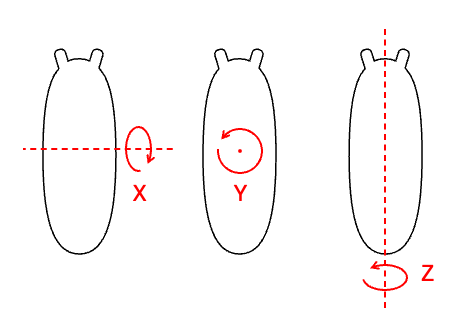

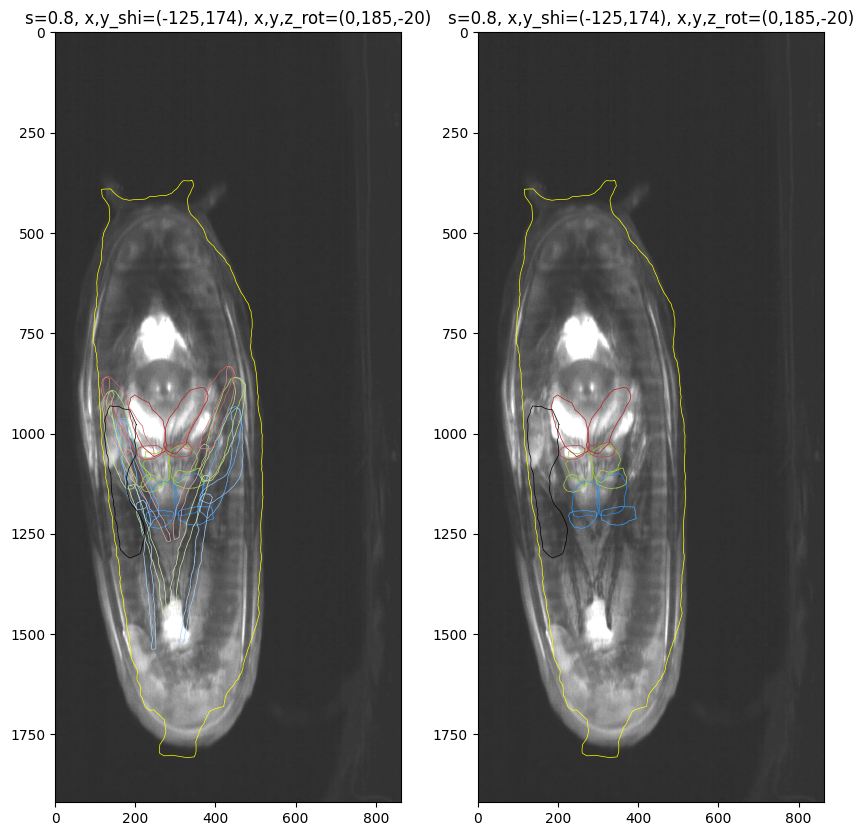

In [ ]:
scale = 0.8
x_shift, y_shift = -125, 174
x_rotation, y_rotation, z_rotation = 0, 185, -20
plot_what = ['Pupa', 'Front', 'Wing']
plot_what = ['']
plot_what = ['Pupa', 'COXA', 'TROCHANTER', 'Wing']
if 'old_ax' not in globals():
    old_ax = None
    old_title = None
old_ax, old_title = align_outlines(ave, coordinates, scale, x_shift, y_shift, x_rotation, y_rotation, z_rotation, plot_what, old_ax, old_title)

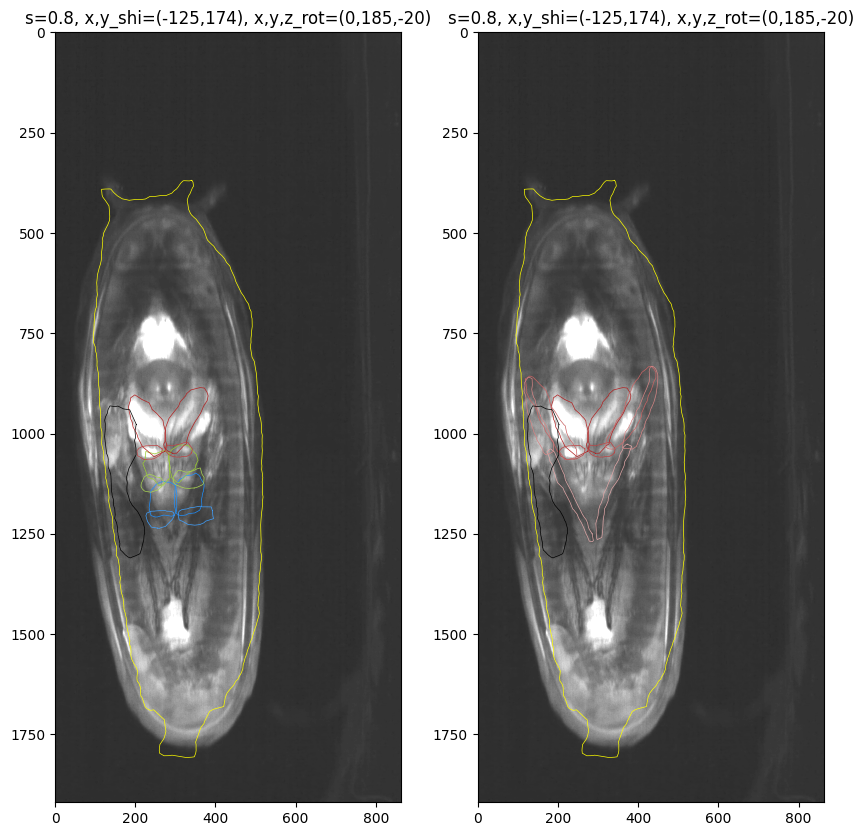

In [25]:
plot_what = ['Pupa', 'Front', 'Wing']
ld_ax, old_title = align_outlines(ave, coordinates, scale, x_shift, y_shift, x_rotation, y_rotation, z_rotation, plot_what, old_ax, old_title)